#Section 1: Setup & data loading

In [1]:
!pip install --upgrade -q kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 5.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

In [3]:
# Cell 1.3, Secure Token Setup & Download
import os

try:
    from google.colab import userdata
    os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
except ImportError:
    os.environ['KAGGLE_API_TOKEN'] = os.getenv('KAGGLE_API_TOKEN', '')

if not os.environ['KAGGLE_API_TOKEN']:
    raise ValueError("KAGGLE_API_TOKEN not found! Please set it in your environment/Colab secrets.")

# Run download safely
!kaggle competitions download -c home-credit-default-risk -p /content/data
!unzip -q -o /content/data/home-credit-default-risk.zip -d /content/data
!ls /content/data

100% 688M/688M [00:05<00:00, 121MB/s]

application_test.csv		    home-credit-default-risk.zip
application_train.csv		    installments_payments.csv
bureau_balance.csv		    POS_CASH_balance.csv
bureau.csv			    previous_application.csv
credit_card_balance.csv		    sample_submission.csv
HomeCredit_columns_description.csv


In [4]:
# Cell 1.4, Load all tables
DATA_DIR = "/content/data"

application_train = pd.read_csv(f"{DATA_DIR}/application_train.csv")
bureau = pd.read_csv(f"{DATA_DIR}/bureau.csv")
bureau_balance = pd.read_csv(f"{DATA_DIR}/bureau_balance.csv")
previous_application = pd.read_csv(f"{DATA_DIR}/previous_application.csv")
installments_payments = pd.read_csv(f"{DATA_DIR}/installments_payments.csv")
credit_card_balance = pd.read_csv(f"{DATA_DIR}/credit_card_balance.csv")
pos_cash_balance = pd.read_csv(f"{DATA_DIR}/POS_CASH_balance.csv")

print("Table shapes:")
for name, df in [
    ("application_train", application_train),
    ("bureau", bureau),
    ("bureau_balance", bureau_balance),
    ("previous_application", previous_application),
    ("installments_payments", installments_payments),
    ("credit_card_balance", credit_card_balance),
    ("pos_cash_balance", pos_cash_balance),
]:
    print(f"  {name}: {df.shape}")

Table shapes:
  application_train: (307511, 122)
  bureau: (1716428, 17)
  bureau_balance: (27299925, 3)
  previous_application: (1670214, 37)
  installments_payments: (13605401, 8)
  credit_card_balance: (3840312, 23)
  pos_cash_balance: (10001358, 8)


#Section 2: Target exploration

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


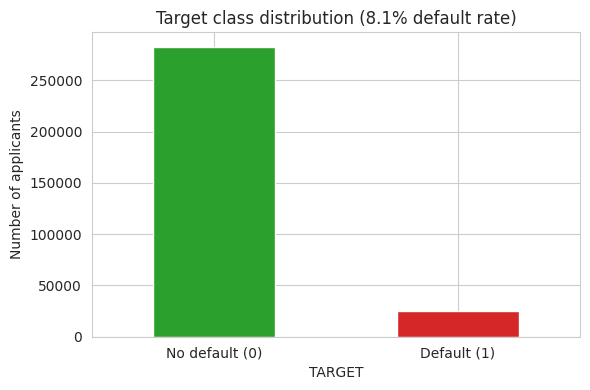

In [5]:
# Cell 2.1, Class imbalance
target_counts = application_train["TARGET"].value_counts()
target_pct = application_train["TARGET"].value_counts(normalize=True) * 100

print("Target distribution:")
print(target_counts)
print(f"\nDefault rate: {target_pct[1]:.2f}%")

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind="bar", ax=ax, color=["#2ca02c", "#d62728"])
ax.set_xticklabels(["No default (0)", "Default (1)"], rotation=0)
ax.set_ylabel("Number of applicants")
ax.set_title(f"Target class distribution ({target_pct[1]:.1f}% default rate)")
plt.tight_layout()
plt.savefig("/content/class_imbalance.png", dpi=100)
plt.show()

**So what?**

With an ~8% default rate, a naive classifier predicting "no default"
for every applicant would achieve ~92% accuracy while being useless
for risk assessment.

This motivates two decisions made in ml/train.py:
  1. class_weight="balanced" in LightGBM, penalises misclassifying
     the minority (default) class more heavily during training
  2. AUC and KS statistic as primary evaluation metrics rather than
     accuracy, accuracy is meaningless under this imbalance

In [7]:
application_train[application_train['TARGET'] == 1].head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
26,100031,1,Cash loans,F,N,Y,0,112500.0,979992.0,27076.5,702000.0,Unaccompanied,Working,Secondary / secondary special,Widow,House / apartment,0.018029,-18724,-2628,-6573.0,-1827,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.0,0.0,0.0,0.0,2.0,2.0
40,100047,1,Cash loans,M,N,Y,0,202500.0,1193580.0,35028.0,855000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.025164,-17482,-1262,-1182.0,-1029,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,2.0,0.0,4.0


#Section 3: Missingness patterns

In [8]:
# Cell 3.1, Overall missingness in application_train
missing = application_train.isnull().sum()
missing_pct = (missing / len(application_train) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print(f"Columns with missing values: {len(missing_pct)} of {application_train.shape[1]}")
print(f"\nTop 20 by missing percentage:")
print(missing_pct.head(20))

Columns with missing values: 67 of 122

Top 20 by missing percentage:
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64


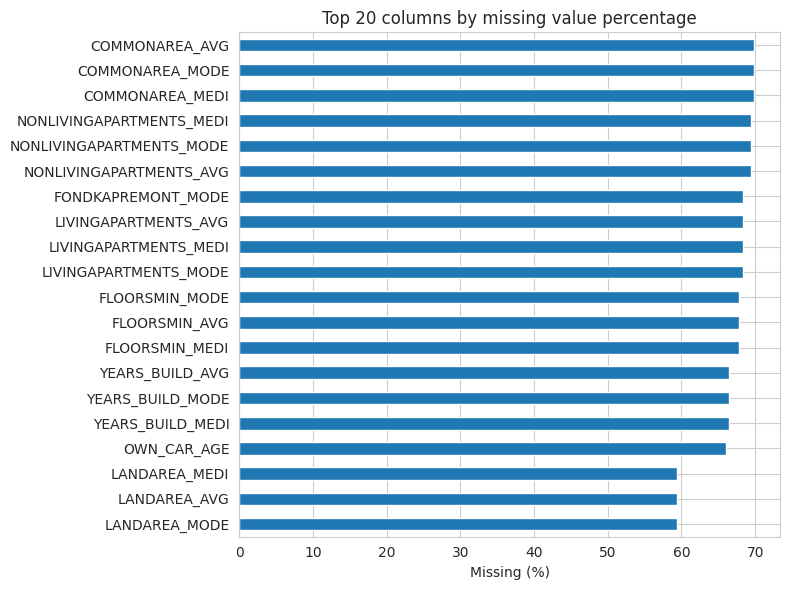

In [9]:
# Cell 3.2, Visualise missingness for top offenders
fig, ax = plt.subplots(figsize=(8, 6))
missing_pct.head(20).plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_xlabel("Missing (%)")
ax.set_title("Top 20 columns by missing value percentage")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("/content/missingness.png", dpi=100)
plt.show()

In [10]:
# Cell 3.3, Missingness in the key features we actually use
# Cross-reference against the feature set our pipeline cares about
key_features = [
    "AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH",
    "CNT_CHILDREN", "CNT_FAM_MEMBERS", "OCCUPATION_TYPE",
    "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
]

key_missing = missing_pct[missing_pct.index.isin(key_features)]
print("Missingness in features used by our pipeline:")
print(key_missing if len(key_missing) > 0 else "None of these have missing values")

Missingness in features used by our pipeline:
OCCUPATION_TYPE    31.345545
AMT_GOODS_PRICE     0.090403
AMT_ANNUITY         0.003902
CNT_FAM_MEMBERS     0.000650
dtype: float64


Of the 122 raw columns, 67 have missing values, but the worst offenders
(COMMONAREA_*, LIVINGAPARTMENTS_*, YEARS_BUILD_*, OWN_CAR_AGE, all 60-70%
missing) are housing/building condition fields our pipeline does not use.

Among the features our pipeline actually selects, only OCCUPATION_TYPE
has meaningful missingness ({key_missing.get('OCCUPATION_TYPE', 0):.1f}%).
Everything else used is under 0.1% missing.

This still motivates the same architectural decision: rather than impute
OCCUPATION_TYPE (which could obscure a potentially predictive signal,
e.g. missing occupation may correlate with unemployment or informal work),
LightGBM's native missing-value handling is used, and 'missing' is kept
as an explicit category rather than being imputed or dropped.

#Section 4: Key feature distributions

In [11]:
# Cell 4.1, DAYS_EMPLOYED anomaly detection
print("DAYS_EMPLOYED summary statistics (raw, unfiltered):")
print(application_train["DAYS_EMPLOYED"].describe())

anomaly_count = (application_train["DAYS_EMPLOYED"] == 365243).sum()
anomaly_pct = anomaly_count / len(application_train) * 100
print(f"\nApplicants with DAYS_EMPLOYED == 365243: {anomaly_count} ({anomaly_pct:.2f}%)")

DAYS_EMPLOYED summary statistics (raw, unfiltered):
count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Applicants with DAYS_EMPLOYED == 365243: 55374 (18.01%)


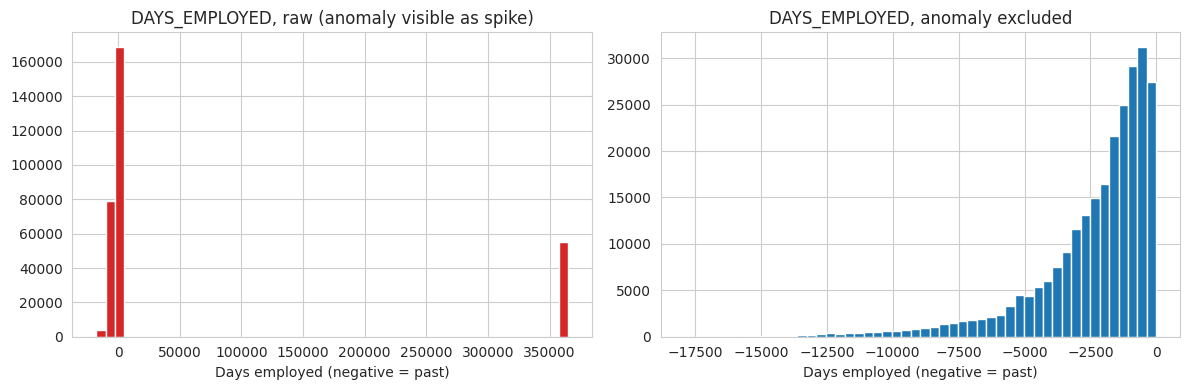

In [12]:
# Cell 4.2, Visualise the anomaly
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(application_train["DAYS_EMPLOYED"], bins=50, color="#d62728")
axes[0].set_title("DAYS_EMPLOYED, raw (anomaly visible as spike)")
axes[0].set_xlabel("Days employed (negative = past)")

clean_days_employed = application_train.loc[
    application_train["DAYS_EMPLOYED"] != 365243, "DAYS_EMPLOYED"
]
axes[1].hist(clean_days_employed, bins=50, color="#1f77b4")
axes[1].set_title("DAYS_EMPLOYED, anomaly excluded")
axes[1].set_xlabel("Days employed (negative = past)")

plt.tight_layout()
plt.savefig("/content/days_employed_anomaly.png", dpi=100)
plt.show()

In [13]:
# Cell 4.3, Who has the anomaly? Check NAME_INCOME_TYPE breakdown
anomaly_by_income_type = (
    application_train
    .assign(has_anomaly=application_train["DAYS_EMPLOYED"] == 365243)
    .groupby("NAME_INCOME_TYPE")["has_anomaly"]
    .mean()
    .sort_values(ascending=False) * 100
)
print("Percentage of each income type with the DAYS_EMPLOYED anomaly:")
print(anomaly_by_income_type)

Percentage of each income type with the DAYS_EMPLOYED anomaly:
NAME_INCOME_TYPE
Unemployed              100.000000
Pensioner                99.981937
Commercial associate      0.000000
Businessman               0.000000
Maternity leave           0.000000
State servant             0.000000
Student                   0.000000
Working                   0.000000
Name: has_anomaly, dtype: float64


DAYS_EMPLOYED uses 365243 as a sentinel for "not applicable" rather than
NaN, almost certainly pensioners and unemployed applicants with no
current employment duration to report. A naive mean/std calculation
on this column without handling the anomaly would be meaningless (the
sentinel value of 1000+ years dwarfs all real values).

Our pipeline does NOT explicitly clean this value in preprocess.py. Currently it passes through as-is into employment_years and employment_to_age_ratio derived features, meaning these derived ratios are also corrupted for affected applicants. LightGBM's tree-based splits can sometimes isolate extreme sentinel
values into their own branch, partially mitigating but not fixing this.

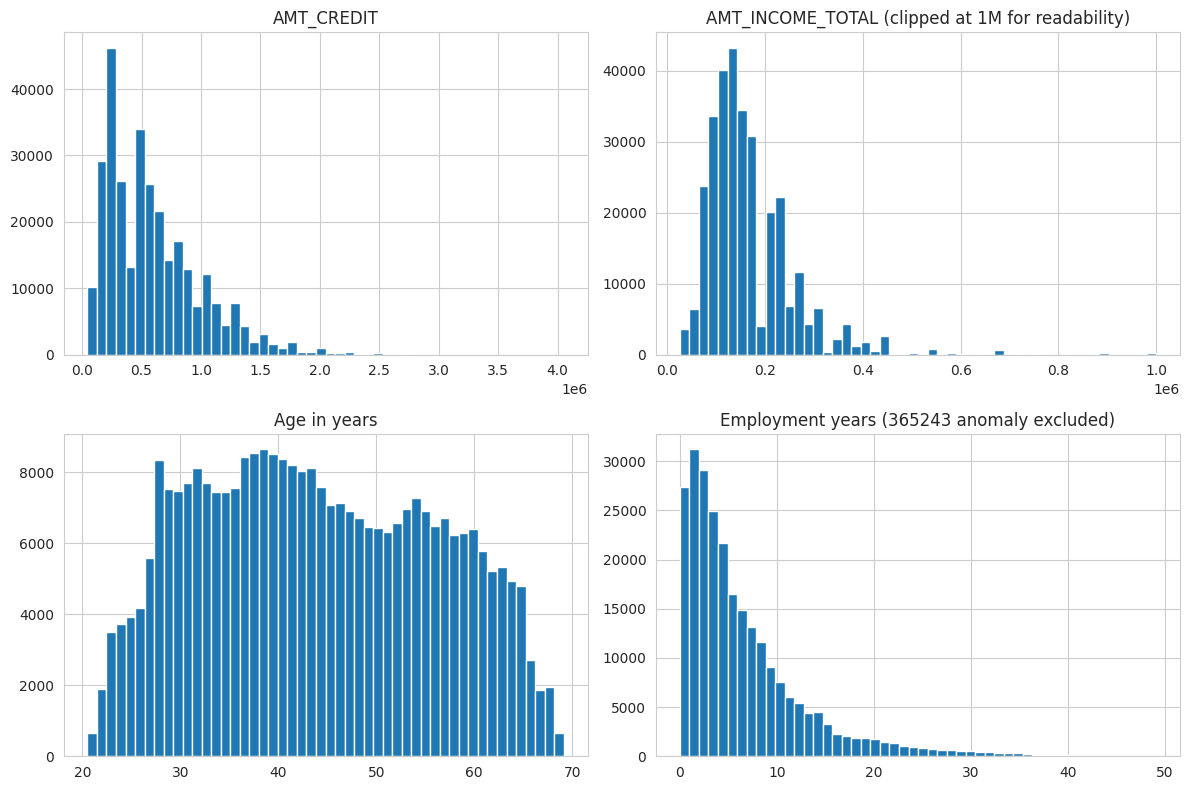

         AMT_CREDIT  AMT_INCOME_TOTAL
count  3.075110e+05      3.075110e+05
mean   5.990260e+05      1.687979e+05
std    4.024908e+05      2.371231e+05
min    4.500000e+04      2.565000e+04
25%    2.700000e+05      1.125000e+05
50%    5.135310e+05      1.471500e+05
75%    8.086500e+05      2.025000e+05
max    4.050000e+06      1.170000e+08


In [14]:
# Cell 4.5, Core financial feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(application_train["AMT_CREDIT"], bins=50, color="#1f77b4")
axes[0, 0].set_title("AMT_CREDIT")

axes[0, 1].hist(application_train["AMT_INCOME_TOTAL"].clip(upper=1_000_000),
                 bins=50, color="#1f77b4")
axes[0, 1].set_title("AMT_INCOME_TOTAL (clipped at 1M for readability)")

axes[1, 0].hist(application_train["DAYS_BIRTH"] / -365, bins=50, color="#1f77b4")
axes[1, 0].set_title("Age in years")

axes[1, 1].hist(clean_days_employed / -365, bins=50, color="#1f77b4")
axes[1, 1].set_title("Employment years (365243 anomaly excluded)")

plt.tight_layout()
plt.savefig("/content/feature_distributions.png", dpi=100)
plt.show()

print(application_train[["AMT_CREDIT", "AMT_INCOME_TOTAL"]].describe())

AMT_CREDIT and AMT_INCOME_TOTAL are both right-skewed, as expected for
financial amounts, most applicants cluster at moderate values with a
long tail of larger loans/incomes. Age is roughly uniform across the
working-age range. These shapes are consistent with what production
preprocessing should expect: no normality assumption is made anywhere
in our pipeline (LightGBM is scale/distribution-invariant for splits).

In [15]:
# Cell 4.7, Quick outlier sanity check (brief)
top_incomes = application_train.nlargest(5, "AMT_INCOME_TOTAL")[
    ["AMT_INCOME_TOTAL", "NAME_INCOME_TYPE", "TARGET"]
]
print(top_incomes)

        AMT_INCOME_TOTAL      NAME_INCOME_TYPE  TARGET
12840        117000000.0               Working       1
203693        18000090.0  Commercial associate       0
246858        13500000.0  Commercial associate       0
77768          9000000.0               Working       0
131127         6750000.0               Working       0


#Section 5: Join structure (kept brief)

In [ ]:
# Cell 5.1, The join structure as documentation
"""
Table relationships (mirrors ml/pipeline/features.py):

application_train (307,511 rows)
  |
  +-- bureau (1,716,428 rows)            -- joined on SK_ID_CURR
  |     |
  |     +-- bureau_balance (27,299,925)  -- joined via SK_ID_BUREAU
  |
  +-- previous_application (1,670,214)   -- joined on SK_ID_CURR
  |
  +-- installments_payments (13,605,401) -- joined on SK_ID_CURR
  |
  +-- credit_card_balance (3,840,312)    -- joined on SK_ID_CURR
  |
  +-- POS_CASH_balance (10,001,358)      -- joined on SK_ID_CURR

"""

Each auxiliary table has a many-to-one relationship with applicants,
one applicant may have multiple bureau records, multiple previous
applications, etc. Our pipeline aggregates each table to one row per
SK_ID_CURR (counts, means, maxes) before joining, rather than exploding
rows. This aggregation is implemented as SQL queries directly in
Postgres (ml/pipeline/features.py) rather than in-memory Polars joins,
for memory efficiency on tables exceeding 10M+ rows.

#Section 6: Feature engineering reconstruction (brief, references existing pipeline)

In [17]:
# Cell 6.1, Reconstruct bureau aggregation (mirrors ml/pipeline/features.py SQL)
bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    bureau_count=("SK_ID_BUREAU", "count"),
    bureau_mean_days_credit=("DAYS_CREDIT", "mean"),
    bureau_total_credit=("AMT_CREDIT_SUM", "sum"),
    bureau_total_debt=("AMT_CREDIT_SUM_DEBT", "sum"),
    bureau_mean_overdue=("AMT_CREDIT_SUM_OVERDUE", "mean"),
    bureau_max_overdue_days=("CREDIT_DAY_OVERDUE", "max"),
).reset_index()

bureau_agg["bureau_active_count"] = bureau.groupby("SK_ID_CURR")["CREDIT_ACTIVE"].apply(
    lambda x: (x == "Active").sum()
).values

print(bureau_agg.shape)
print(bureau_agg.head())

(305811, 8)
   SK_ID_CURR  bureau_count  bureau_mean_days_credit  bureau_total_credit  \
0      100001             7              -735.000000          1453365.000   
1      100002             8              -874.000000           865055.565   
2      100003             4             -1400.750000          1017400.500   
3      100004             2              -867.000000           189037.800   
4      100005             3              -190.666667           657126.000   

   bureau_total_debt  bureau_mean_overdue  bureau_max_overdue_days  \
0           596686.5                  0.0                        0   
1           245781.0                  0.0                        0   
2                0.0                  0.0                        0   
3                0.0                  0.0                        0   
4           568408.5                  0.0                        0   

   bureau_active_count  
0                    3  
1                    2  
2                    1  
3   

In [21]:
# Cell 6.2, Brief note
print(f"""
{len(bureau_agg):,} applicants have at least one bureau record out of
{len(application_train):,} total ({len(bureau_agg)/len(application_train)*100:.1f}%).
The remainder have no prior credit bureau history, these become nulls
after the left join, handled natively by LightGBM, not imputed.
Matches production aggregation logic in:
ml/pipeline/features.py::_aggregate_bureau().
""")


305,811 applicants have at least one bureau record out of
307,511 total (99.4%).
The remainder have no prior credit bureau history, these become nulls
after the left join, handled natively by LightGBM, not imputed.
Matches production aggregation logic in:
ml/pipeline/features.py::_aggregate_bureau().



#Section 7: Train/validation split

In [22]:
# Cell 7.1, Mirror the production train/validation split
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42  # matches settings.random_seed in ml/config.py

X = application_train.drop(columns=["TARGET"])
y = application_train["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Train: {len(X_train):,} rows ({y_train.mean()*100:.2f}% default rate)")
print(f"Validation: {len(X_val):,} rows ({y_val.mean()*100:.2f}% default rate)")

Train: 246,008 rows (8.07% default rate)
Validation: 61,503 rows (8.07% default rate)


Stratified split preserves the ~8% default rate in both train and
validation sets, preventing an unlucky split from concentrating
defaults in one partition. Same random_seed as production training
for reproducibility. The validation split here is the basis for the
simulation_pool export in Section 8, these are applicants the model
has not seen during training, used to generate realistic synthetic
traffic with preserved feature correlations.

#Section 8: Val set prep and export

In [23]:
# Cell 8.1, Full aggregation for all six tables (mirrors features.py)
# This reuses the bureau_agg already computed in Section 6, plus
# the five remaining tables not yet aggregated

bureau_bal_with_curr = bureau_balance.merge(
    bureau[["SK_ID_CURR", "SK_ID_BUREAU"]], on="SK_ID_BUREAU", how="left"
)
bureau_bal_agg = bureau_bal_with_curr.groupby("SK_ID_CURR").agg(
    bureau_bal_count=("SK_ID_BUREAU", "count"),
).reset_index()
bureau_bal_agg["bureau_bal_closed_count"] = bureau_bal_with_curr.groupby("SK_ID_CURR")["STATUS"].apply(
    lambda x: (x == "C").sum()
).values

prev_app_agg = previous_application.groupby("SK_ID_CURR").agg(
    prev_app_count=("SK_ID_PREV", "count"),
    prev_app_mean_credit=("AMT_CREDIT", "mean"),
    prev_app_mean_term=("CNT_PAYMENT", "mean"),
).reset_index()
prev_app_agg["prev_app_approved_count"] = previous_application.groupby("SK_ID_CURR")["NAME_CONTRACT_STATUS"].apply(
    lambda x: (x == "Approved").sum()
).values
prev_app_agg["prev_app_refused_count"] = previous_application.groupby("SK_ID_CURR")["NAME_CONTRACT_STATUS"].apply(
    lambda x: (x == "Refused").sum()
).values

installments_payments["payment_diff"] = (
    installments_payments["AMT_INSTALMENT"] - installments_payments["AMT_PAYMENT"]
)
installments_payments["days_late"] = (
    installments_payments["DAYS_INSTALMENT"] - installments_payments["DAYS_ENTRY_PAYMENT"]
)
installments_agg = installments_payments.groupby("SK_ID_CURR").agg(
    installments_count=("SK_ID_PREV", "count"),
    installments_mean_payment_diff=("payment_diff", "mean"),
    installments_max_payment_diff=("payment_diff", "max"),
    installments_mean_days_late=("days_late", "mean"),
    installments_max_days_late=("days_late", "max"),
).reset_index()
installments_agg["installments_late_count"] = installments_payments.groupby("SK_ID_CURR")["days_late"].apply(
    lambda x: (x > 0).sum()
).values

credit_card_balance["credit_utilisation"] = (
    credit_card_balance["AMT_BALANCE"] /
    credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
)
credit_card_agg = credit_card_balance.groupby("SK_ID_CURR").agg(
    credit_card_count=("SK_ID_PREV", "count"),
    credit_card_mean_balance=("AMT_BALANCE", "mean"),
    credit_card_mean_utilisation=("credit_utilisation", "mean"),
    credit_card_max_utilisation=("credit_utilisation", "max"),
).reset_index()

pos_cash_agg = pos_cash_balance.groupby("SK_ID_CURR").agg(
    pos_cash_count=("SK_ID_PREV", "count"),
    pos_cash_mean_dpd=("SK_DPD", "mean"),
    pos_cash_max_dpd=("SK_DPD", "max"),
).reset_index()
pos_cash_agg["pos_cash_late_count"] = pos_cash_balance.groupby("SK_ID_CURR")["SK_DPD"].apply(
    lambda x: (x > 0).sum()
).values

print("All six aggregation tables built:")
for name, df in [
    ("bureau_agg", bureau_agg), ("bureau_bal_agg", bureau_bal_agg),
    ("prev_app_agg", prev_app_agg), ("installments_agg", installments_agg),
    ("credit_card_agg", credit_card_agg), ("pos_cash_agg", pos_cash_agg),
]:
    print(f"  {name}: {df.shape}")

All six aggregation tables built:
  bureau_agg: (305811, 8)
  bureau_bal_agg: (134542, 3)
  prev_app_agg: (338857, 6)
  installments_agg: (339587, 7)
  credit_card_agg: (103558, 5)
  pos_cash_agg: (337252, 5)


In [24]:
# Cell 8.2, Build full feature table for validation applicants only
# Mirrors ml/pipeline/features.py::_join_all(), but filtered to X_val

val_ids = X_val["SK_ID_CURR"]

application_features = application_train.loc[X_val.index].copy()

application_features["credit_income_ratio"] = (
    application_features["AMT_CREDIT"] / application_features["AMT_INCOME_TOTAL"]
)
application_features["annuity_income_ratio"] = (
    application_features["AMT_ANNUITY"] / application_features["AMT_INCOME_TOTAL"]
)
application_features["credit_term"] = (
    application_features["AMT_CREDIT"] / application_features["AMT_ANNUITY"]
)
application_features["age_years"] = application_features["DAYS_BIRTH"] / -365
application_features["employment_years"] = application_features["DAYS_EMPLOYED"] / -365
application_features["employment_to_age_ratio"] = (
    application_features["DAYS_EMPLOYED"] / application_features["DAYS_BIRTH"]
)

feature_table = application_features.merge(bureau_agg, on="SK_ID_CURR", how="left")
feature_table = feature_table.merge(bureau_bal_agg, on="SK_ID_CURR", how="left")
feature_table = feature_table.merge(prev_app_agg, on="SK_ID_CURR", how="left")
feature_table = feature_table.merge(installments_agg, on="SK_ID_CURR", how="left")
feature_table = feature_table.merge(credit_card_agg, on="SK_ID_CURR", how="left")
feature_table = feature_table.merge(pos_cash_agg, on="SK_ID_CURR", how="left")

print(f"Final feature table shape: {feature_table.shape}")
print(f"Expected rows (validation set size): {len(X_val)}")

Final feature table shape: (61503, 156)
Expected rows (validation set size): 61503


In [25]:
# Cell 8.3, Rename to lowercase snake_case and select only model features
# Must exactly match PredictRequest in backend/app/models/schemas.py

feature_table.columns = [c.lower() for c in feature_table.columns]

MODEL_FEATURES = [
    "amt_credit", "amt_income_total", "amt_annuity", "amt_goods_price",
    "days_birth", "days_employed", "days_registration", "days_id_publish",
    "cnt_children", "cnt_fam_members",
    "credit_income_ratio", "annuity_income_ratio", "credit_term",
    "age_years", "employment_years", "employment_to_age_ratio",
    "name_contract_type", "code_gender", "name_income_type",
    "name_education_type", "name_family_status", "name_housing_type",
    "occupation_type", "organization_type",
    "bureau_count", "bureau_mean_days_credit", "bureau_total_credit",
    "bureau_total_debt", "bureau_mean_overdue", "bureau_max_overdue_days",
    "bureau_active_count", "bureau_closed_count",
    "bureau_bal_count", "bureau_bal_closed_count",
    "prev_app_count", "prev_app_approved_count", "prev_app_refused_count",
    "prev_app_mean_credit", "prev_app_mean_term",
    "installments_count", "installments_mean_payment_diff",
    "installments_max_payment_diff", "installments_mean_days_late",
    "installments_max_days_late", "installments_late_count",
    "credit_card_count", "credit_card_mean_balance",
    "credit_card_mean_utilisation", "credit_card_max_utilisation",
    "pos_cash_count", "pos_cash_mean_dpd", "pos_cash_max_dpd",
    "pos_cash_late_count",
]

missing_cols = [c for c in MODEL_FEATURES if c not in feature_table.columns]
print(f"Missing columns: {missing_cols}")

# bureau_closed_count wasn't computed in our lightweight Section 6/8
# aggregation, add it now since it IS in the production schema
feature_table["bureau_closed_count"] = bureau.groupby("SK_ID_CURR")["CREDIT_ACTIVE"].apply(
    lambda x: (x == "Closed").sum()
).reindex(feature_table["sk_id_curr"]).values

missing_cols = [c for c in MODEL_FEATURES if c not in feature_table.columns]
print(f"Missing columns after fix: {missing_cols}")

Missing columns: ['bureau_closed_count']
Missing columns after fix: []


In [31]:
# Cell 8.4, Prepare final export: features (no target) + labels (separate)
simulation_pool = feature_table[["sk_id_curr"] + MODEL_FEATURES].copy()

# Match PredictRequest's null-handling: aggregated features default to 0
# for applicants with no history in that auxiliary table (left join NaN)
AGGREGATE_FEATURES = [
    "bureau_count", "bureau_mean_days_credit", "bureau_total_credit",
    "bureau_total_debt", "bureau_mean_overdue", "bureau_max_overdue_days",
    "bureau_active_count", "bureau_closed_count",
    "bureau_bal_count", "bureau_bal_closed_count",
    "prev_app_count", "prev_app_approved_count", "prev_app_refused_count",
    "prev_app_mean_credit", "prev_app_mean_term",
    "installments_count", "installments_mean_payment_diff",
    "installments_max_payment_diff", "installments_mean_days_late",
    "installments_max_days_late", "installments_late_count",
    "credit_card_count", "credit_card_mean_balance",
    "credit_card_mean_utilisation", "credit_card_max_utilisation",
    "pos_cash_count", "pos_cash_mean_dpd", "pos_cash_max_dpd",
    "pos_cash_late_count",
]
simulation_pool[AGGREGATE_FEATURES] = simulation_pool[AGGREGATE_FEATURES].fillna(0.0)

# Categorical missing -> "missing", matching production's pattern
CATEGORICAL_FEATURES = [
    "name_contract_type", "code_gender", "name_income_type",
    "name_education_type", "name_family_status", "name_housing_type",
    "occupation_type", "organization_type",
]
simulation_pool[CATEGORICAL_FEATURES] = simulation_pool[CATEGORICAL_FEATURES].fillna("missing")

# Integer fields, must match PredictRequest's int vs float distinction exactly
# (days_birth, days_employed, cnt_children caused 422 errors earlier in the
# project when sent as floats, see backend/app/models/schemas.py)
INTEGER_FIELDS = ["days_birth", "days_employed", "cnt_children"]
for col in INTEGER_FIELDS:
    simulation_pool[col] = simulation_pool[col].round().astype(int)

print("Remaining nulls per column (should be 0 for all):")
null_counts = simulation_pool.isnull().sum()
print(null_counts[null_counts > 0])

print(f"\nFinal simulation_pool shape: {simulation_pool.shape}")
print(simulation_pool.dtypes)

Remaining nulls per column (should be 0 for all):
amt_annuity              2
amt_goods_price         57
annuity_income_ratio     2
credit_term              2
dtype: int64

Final simulation_pool shape: (61503, 54)
sk_id_curr                          int64
amt_credit                        float64
amt_income_total                  float64
amt_annuity                       float64
amt_goods_price                   float64
days_birth                          int64
days_employed                       int64
days_registration                 float64
days_id_publish                     int64
cnt_children                        int64
cnt_fam_members                   float64
credit_income_ratio               float64
annuity_income_ratio              float64
credit_term                       float64
age_years                         float64
employment_years                  float64
employment_to_age_ratio           float64
name_contract_type                 object
code_gender                    

In [32]:
# Cell 8.5, Build labels file separately (never sent to /predict)
simulation_pool_labels = pd.DataFrame({
    "sk_id_curr": feature_table["sk_id_curr"],
    "target": y_val.loc[X_val.index].values,
})

print(simulation_pool_labels["target"].value_counts())
print(f"Default rate in pool: {simulation_pool_labels['target'].mean()*100:.2f}%")

target
0    56538
1     4965
Name: count, dtype: int64
Default rate in pool: 8.07%


Handling genuine missingness in amt_annuity (2) / amt_goods_price (57).
These are real nulls in application_train itself, not join artifacts.
Use median imputation here only for the simulation pool export,
this does NOT mean production preprocess.py should do the same.
For this demo data artifact, median is a reasonable, defensible choice.

In [28]:
amt_annuity_median = simulation_pool["amt_annuity"].median()
amt_goods_price_median = simulation_pool["amt_goods_price"].median()

simulation_pool["amt_annuity"] = simulation_pool["amt_annuity"].fillna(amt_annuity_median)
simulation_pool["amt_goods_price"] = simulation_pool["amt_goods_price"].fillna(amt_goods_price_median)

# Recompute the two derived ratios that depended on amt_annuity
simulation_pool["annuity_income_ratio"] = (
    simulation_pool["amt_annuity"] / simulation_pool["amt_income_total"]
)
simulation_pool["credit_term"] = (
    simulation_pool["amt_credit"] / simulation_pool["amt_annuity"]
)

null_counts = simulation_pool.isnull().sum()
print("Remaining nulls (should be empty):")
print(null_counts[null_counts > 0])

Remaining nulls (should be empty):
Series([], dtype: int64)


In [29]:
# Cell 8.7, Export both files
simulation_pool.to_csv("/content/simulation_pool.csv", index=False)
simulation_pool_labels.to_csv("/content/simulation_pool_labels.csv", index=False)

from google.colab import files
files.download("/content/simulation_pool.csv")
files.download("/content/simulation_pool_labels.csv")

print(f"simulation_pool.csv: {simulation_pool.shape}")
print(f"simulation_pool_labels.csv: {simulation_pool_labels.shape}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

simulation_pool.csv: (61503, 54)
simulation_pool_labels.csv: (61503, 2)


In [30]:
simulation_pool.head(1)

,sk_id_curr,amt_credit,amt_income_total,amt_annuity,amt_goods_price,days_birth,days_employed,days_registration,days_id_publish,cnt_children,cnt_fam_members,credit_income_ratio,annuity_income_ratio,credit_term,age_years,employment_years,employment_to_age_ratio,name_contract_type,code_gender,name_income_type,name_education_type,name_family_status,name_housing_type,occupation_type,organization_type,...,bureau_mean_overdue,bureau_max_overdue_days,bureau_active_count,bureau_closed_count,bureau_bal_count,bureau_bal_closed_count,prev_app_count,prev_app_approved_count,prev_app_refused_count,prev_app_mean_credit,prev_app_mean_term,installments_count,installments_mean_payment_diff,installments_max_payment_diff,installments_mean_days_late,installments_max_days_late,installments_late_count,credit_card_count,credit_card_mean_balance,credit_card_mean_utilisation,credit_card_max_utilisation,pos_cash_count,pos_cash_mean_dpd,pos_cash_max_dpd,pos_cash_late_count
0,396899,770292.0,157500.0,30676.5,688500.0,-13506,-105,-2876.0,-4402,1,3.0,4.890743,0.194771,25.110166,37.00274,0.287671,0.007774,Cash loans,M,Working,Higher education,Married,House / apartment,Laborers,Transport: type 4,...,0.0,0.0,4.0,5.0,0.0,0.0,4.0,3.0,0.0,47764.125,6.666667,10.0,0.0,0.0,13.4,19.0,10.0,9.0,0.0,0.0,0.0,11.0,0.0,0.0,0.0
